✅ Image loaded successfully!
Shape: (1295, 1089, 3)
Size: 4230765
Datatype: uint8


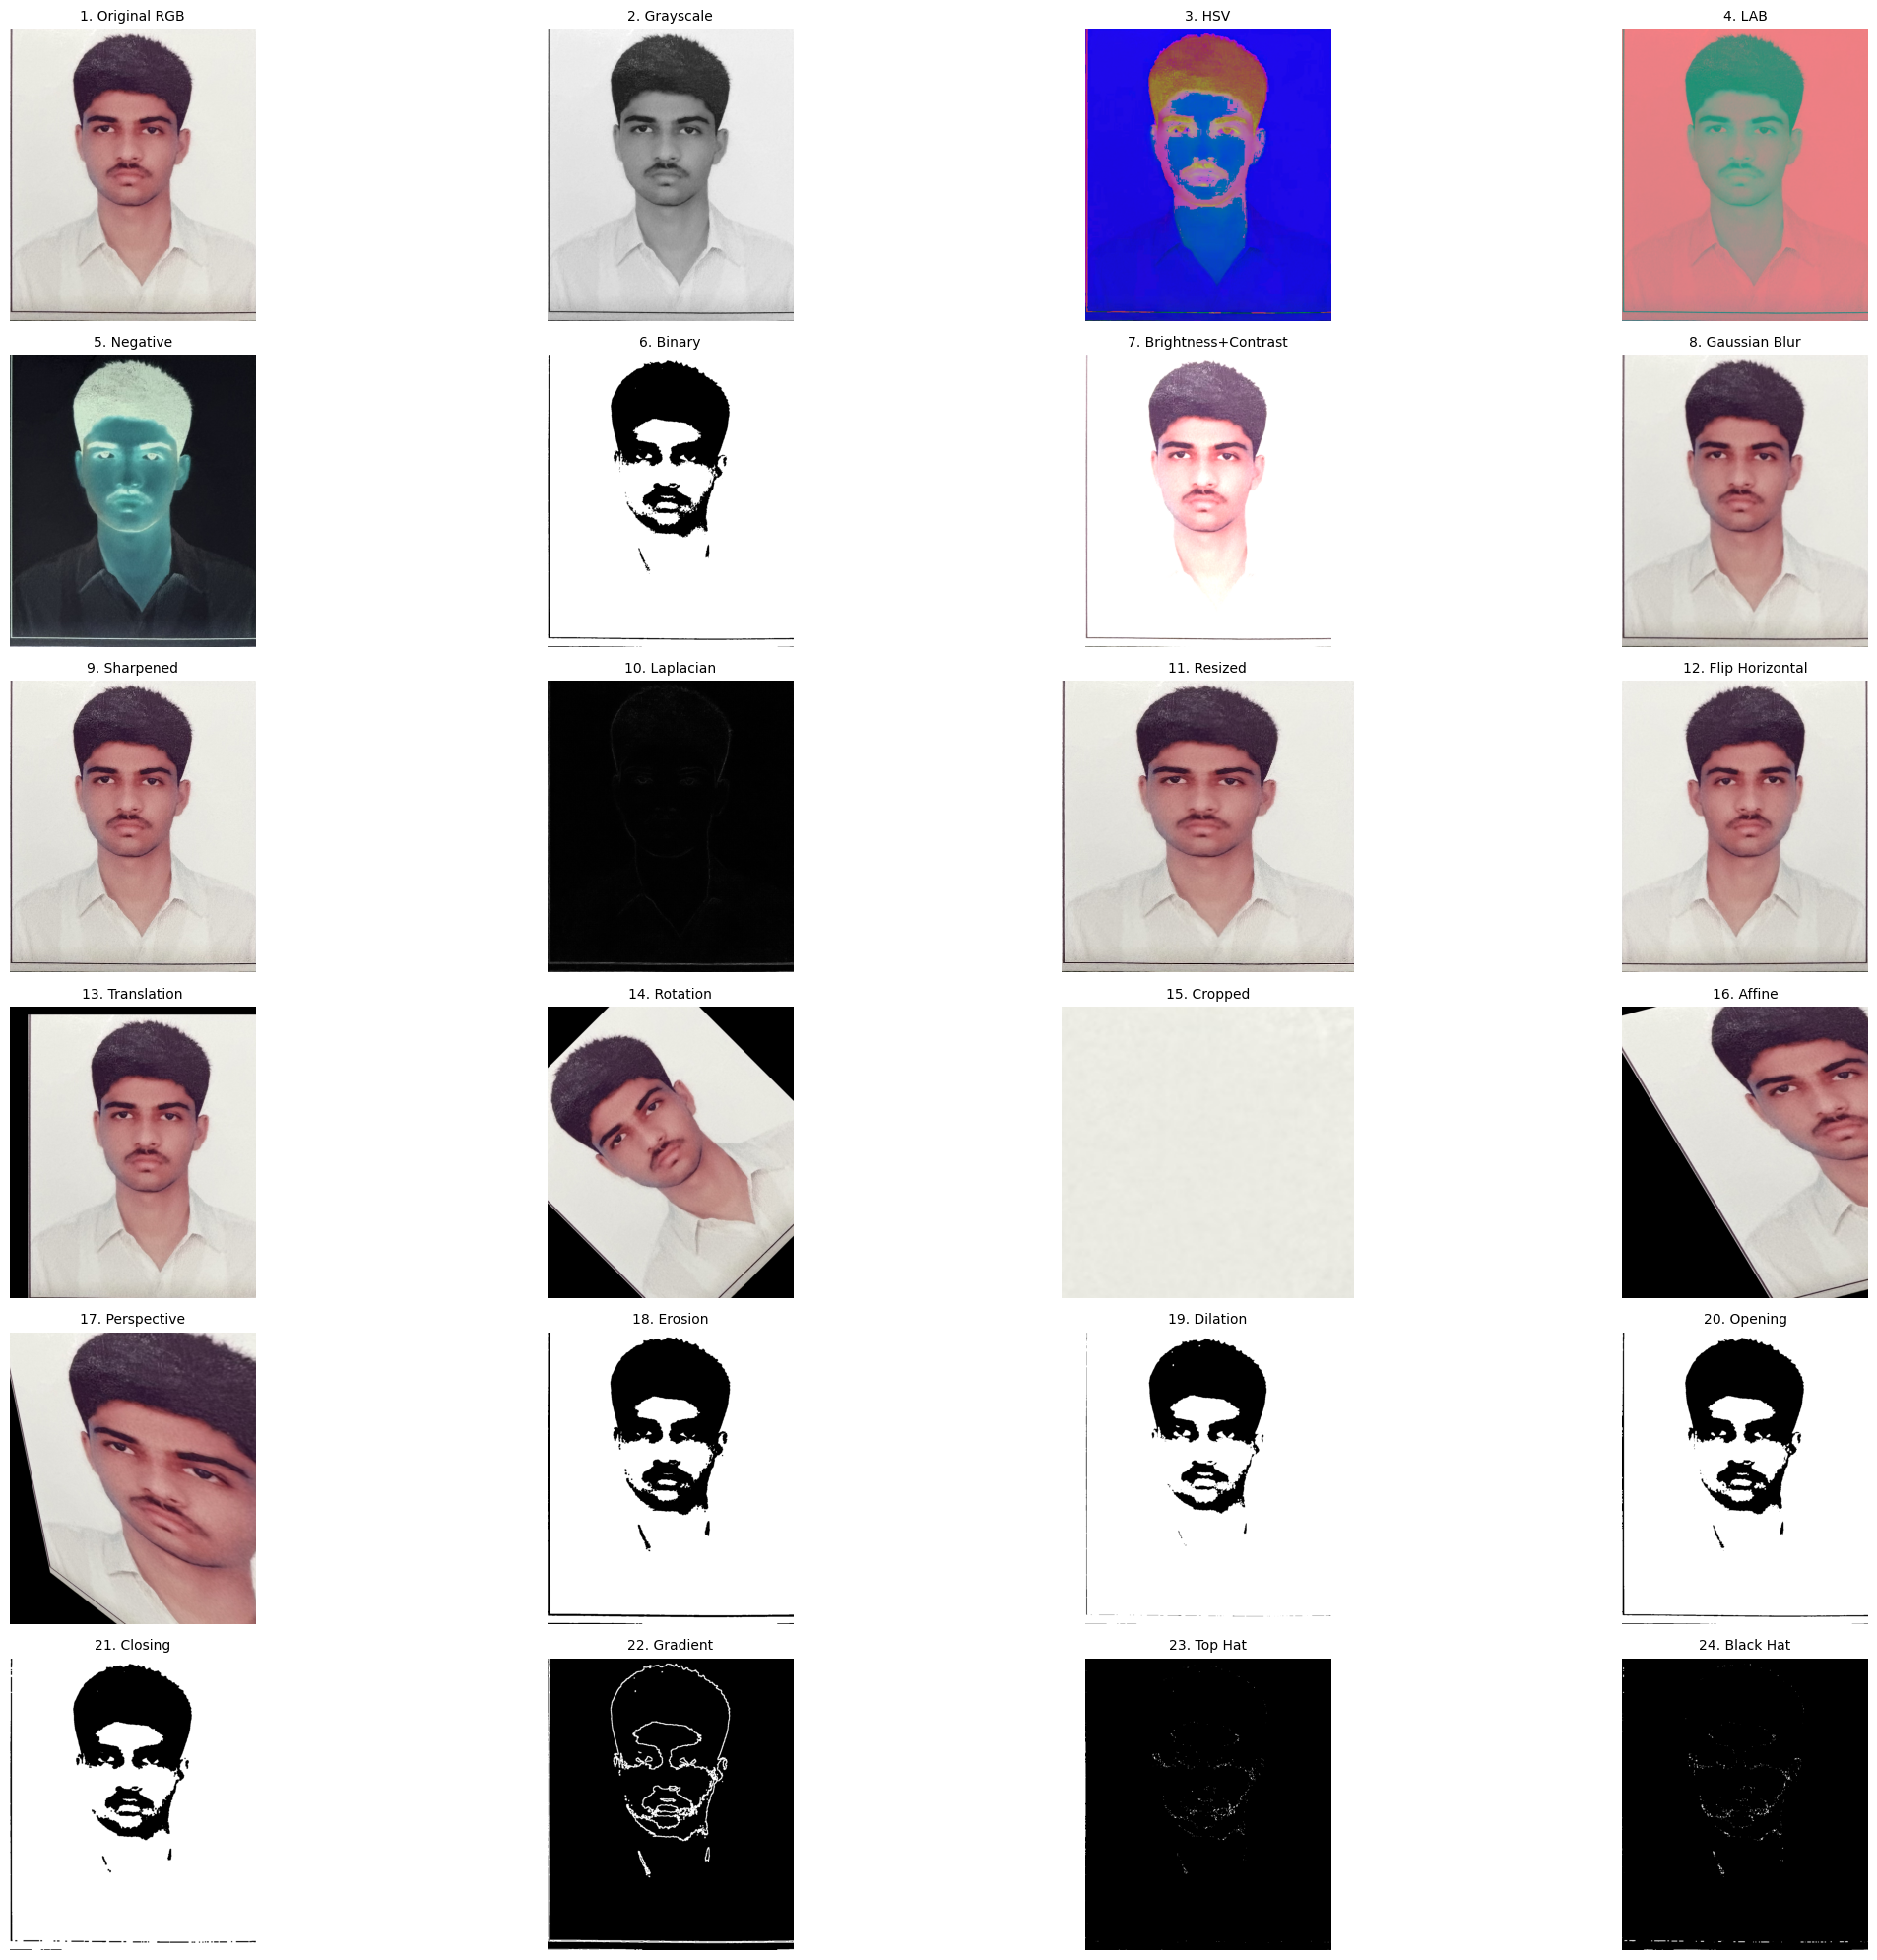

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD IMAGE
# ==============================
img = cv2.imread("image.jpg")   # put your image in same folder

if img is None:
    print("❌ Error: image.jpg not found!")
else:
    print("✅ Image loaded successfully!")
    print("Shape:", img.shape)
    print("Size:", img.size)
    print("Datatype:", img.dtype)

    # Convert BGR to RGB for correct display in matplotlib
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    rows, cols = gray.shape

    # ==============================
    # 2. BASIC CONVERSIONS
    # ==============================
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    # Negative transformation
    negative = 255 - rgb

    # Binary threshold
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    # ==============================
    # 3. BRIGHTNESS / CONTRAST
    # ==============================
    brightness = 30
    contrast = 1.5
    bright_contrast = cv2.convertScaleAbs(rgb, alpha=contrast, beta=brightness)

    # ==============================
    # 4. FILTERS / SHARPENING
    # ==============================
    blurred = cv2.GaussianBlur(rgb, (7, 7), 0)

    kernel_sharp = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])
    sharpened = cv2.filter2D(rgb, -1, kernel_sharp)

    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))

    # ==============================
    # 5. GEOMETRIC TRANSFORMATIONS
    # ==============================
    # Resize
    resized = cv2.resize(rgb, (300, 300))

    # Flip
    flip_h = cv2.flip(rgb, 1)   # horizontal
    flip_v = cv2.flip(rgb, 0)   # vertical

    # Translation
    M_translate = np.float32([[1, 0, 80],
                              [0, 1, 40]])
    translated = cv2.warpAffine(rgb, M_translate, (cols, rows))

    # Rotation
    M_rotate = cv2.getRotationMatrix2D((cols / 2, rows / 2), 45, 1)
    rotated = cv2.warpAffine(rgb, M_rotate, (cols, rows))

    # Crop
    y1, y2 = 50, min(250, rows)
    x1, x2 = 50, min(250, cols)
    cropped = rgb[y1:y2, x1:x2]

    # Affine Transform
    if rows >= 250 and cols >= 250:
        pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
        pts2 = np.float32([[10, 100], [200, 50], [100, 250]])
    else:
        pts1 = np.float32([[10, 10], [cols//2, 10], [10, rows//2]])
        pts2 = np.float32([[20, rows//4], [cols//2, 20], [cols//4, rows//2]])

    M_affine = cv2.getAffineTransform(pts1, pts2)
    affine = cv2.warpAffine(rgb, M_affine, (cols, rows))

    # Perspective Transform
    if rows >= 300 and cols >= 300:
        pts1_p = np.float32([[50, 50], [300, 50], [50, 300], [300, 300]])
        pts2_p = np.float32([[0, 0], [250, 0], [50, 250], [300, 300]])
    else:
        pts1_p = np.float32([[10, 10], [cols-10, 10], [10, rows-10], [cols-10, rows-10]])
        pts2_p = np.float32([[0, 0], [cols-30, 0], [20, rows-30], [cols-1, rows-1]])

    M_persp = cv2.getPerspectiveTransform(pts1_p, pts2_p)
    perspective = cv2.warpPerspective(rgb, M_persp, (cols, rows))

    # ==============================
    # 6. MORPHOLOGICAL OPERATIONS
    # ==============================
    kernel = np.ones((5, 5), np.uint8)

    erosion = cv2.erode(binary, kernel, iterations=1)
    dilation = cv2.dilate(binary, kernel, iterations=1)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
    tophat = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)
    blackhat = cv2.morphologyEx(binary, cv2.MORPH_BLACKHAT, kernel)

    # ==============================
    # 7. DISPLAY ALL RESULTS
    # ==============================
    images = [
        rgb, gray, hsv, lab, negative,
        binary, bright_contrast, blurred, sharpened, laplacian,
        resized, flip_h, translated, rotated, cropped,
        affine, perspective, erosion, dilation, opening,
        closing, gradient, tophat, blackhat
    ]

    titles = [
        "1. Original RGB", "2. Grayscale", "3. HSV", "4. LAB", "5. Negative",
        "6. Binary", "7. Brightness+Contrast", "8. Gaussian Blur", "9. Sharpened", "10. Laplacian",
        "11. Resized", "12. Flip Horizontal", "13. Translation", "14. Rotation", "15. Cropped",
        "16. Affine", "17. Perspective", "18. Erosion", "19. Dilation", "20. Opening",
        "21. Closing", "22. Gradient", "23. Top Hat", "24. Black Hat"
    ]

    plt.figure(figsize=(24, 20))

    for i in range(len(images)):
        plt.subplot(6, 4, i + 1)

        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            # hsv/lab displayed as raw for demonstration
            plt.imshow(images[i])

        plt.title(titles[i], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()